#### **TASK 0 : Course project dataset exploration**
a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using .describe()) and creating at least 2 visualizations of the data. (1p)

**a)**

I will use YouTube API Platform (https://developers.google.com/youtube/v3) which I have already registered and obtained the API key.

**b)**

YouTube API contains nearly all information on the YouTube platform, including video titles, video IDs, published regions, view counts, like counts, comment counts, tags (keywords associating the video), duration. I plan to analyze the "Golden Upload Time". By extracting the hour and day from the publishedAt timestamp, I will investigate which time slots correlate with the highest average viewCount to determine the optimal posting schedule for creators.

**c) Shown in the next three cells:**

By using **.describe()** to calculate the statistics data such us likeCount, viewCount, and commentCount, we observe a highly right-skewed distribution in the trendy videos in the US. Additionally, the high standard deviation shows that even among trending videos, the performance varies significantly.

For the first visualization of the data, I analyzed the "Correlation between viewCount and likeCount". The outlier in the upper-right corner, a music video by Laufey, highlights an extreme positive correlation between viewCount and likeCount, indicating exceptionally high audience engagement and fan loyalty.

The second visualization is the "Distribution of Upload Hours ". By looking at the 24-hour distribution, we can see which hours are the most popular for videos that enter the trending list, providing insights into the video upload scheduling for top creators.

In [6]:
!pip install google-api-python-client

In [46]:
from googleapiclient.discovery import build
import pandas as pd

API_KEY = '' 
REGION_CODE = 'US' 

youtube = build('youtube', 'v3', developerKey=API_KEY)

def get_top_trending_clean(region='US'):
    all_items = []
    next_page_token = None
    
    for _ in range(2):
        video_response = youtube.videos().list(
            part='statistics,snippet',
            chart='mostPopular',
            regionCode=region,
            maxResults=50,
            pageToken=next_page_token
        ).execute()
        
        all_items.extend(video_response.get('items', []))
        next_page_token = video_response.get('nextPageToken')
        
        if not next_page_token:
            break

    data = []
    for item in all_items:
        v_id = item['id']
        stats = item['statistics']
        data.append({
            'title': item['snippet']['title'],
            'channelTitle': item['snippet']['channelTitle'],
            'publishedAt': item['snippet']['publishedAt'],
            'url': f'https://www.youtube.com/watch?v={v_id}',
            'viewCount': int(stats.get('viewCount', 0)),
            'likeCount': int(stats.get('likeCount', 0)),
            'commentCount': int(stats.get('commentCount', 0))
        })
    
    df = pd.DataFrame(data)

    condition = (df['viewCount'] == 0) & (df['likeCount'] == 0) & (df['commentCount'] == 0)
    df_filtered = df[~condition].copy()
    
    df_final = df_filtered.head(50).reset_index(drop=True)
    
    df_final.index += 1
    
    return df_final

df_result = get_top_trending_clean(REGION_CODE)

df_result.to_csv('YTtop50_intheUS.csv', index_label='ID', encoding='utf-8-sig')

print(df_result.head())

                                               title  \
1                            Allstar JR - Mob Untied   
2                   Focker-In-Law | Official Trailer   
3  YoungBoy Never Broke Again - Bruce Wayne [Offi...   
4            GODZILLA MINUS ZERO | First Look Teaser   
5  Los Gemelos De Sinaloa X Clave Especial X Fuer...   

                 channelTitle           publishedAt  \
1                  Allstar JR  2026-04-15T23:24:10Z   
2          Universal Pictures  2026-04-16T00:27:51Z   
3  YoungBoy Never Broke Again  2026-04-15T21:00:03Z   
4   GODZILLA OFFICIAL by TOHO  2026-04-14T22:55:07Z   
5              CLAVE ESPECIAL  2026-04-15T00:00:02Z   

                                           url  viewCount  likeCount  \
1  https://www.youtube.com/watch?v=EImIUIy1Lp4     330171      29941   
2  https://www.youtube.com/watch?v=vyISuWUWcFs    1428999      24815   
3  https://www.youtube.com/watch?v=2wI4_-aMSk0     377633      52763   
4  https://www.youtube.com/watch?v=n-NDYWPXp

statistics
          viewCount      likeCount  commentCount
count  5.000000e+01      50.000000     50.000000
mean   6.165993e+05   33118.960000   2381.160000
std    1.046036e+06   82207.772672   4550.264062
min    5.780700e+04     503.000000      0.000000
25%    1.364912e+05    5870.250000    346.500000
50%    2.351535e+05   11228.500000    791.000000
75%    4.019588e+05   23162.750000   1558.500000
max    6.001746e+06  543903.000000  24305.000000


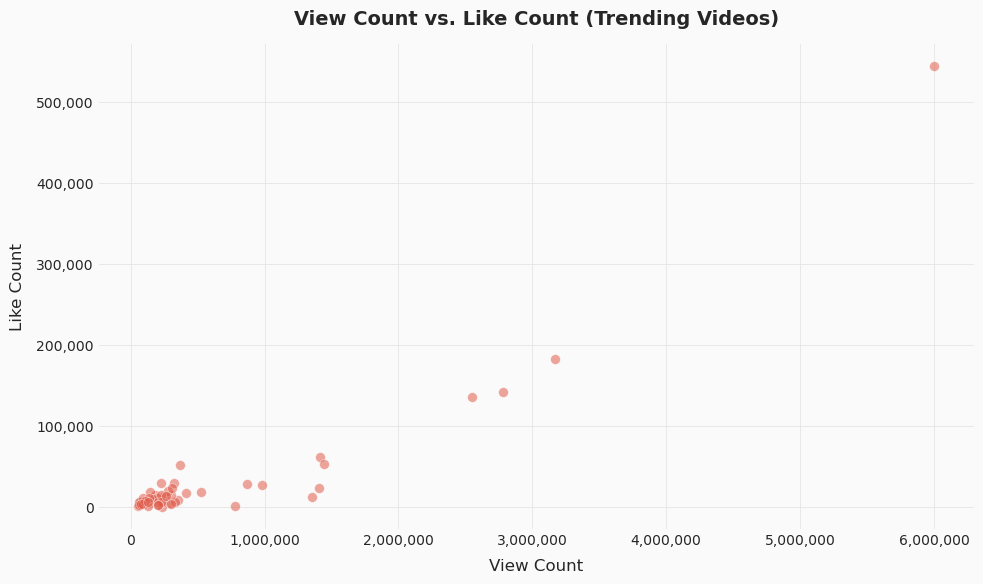

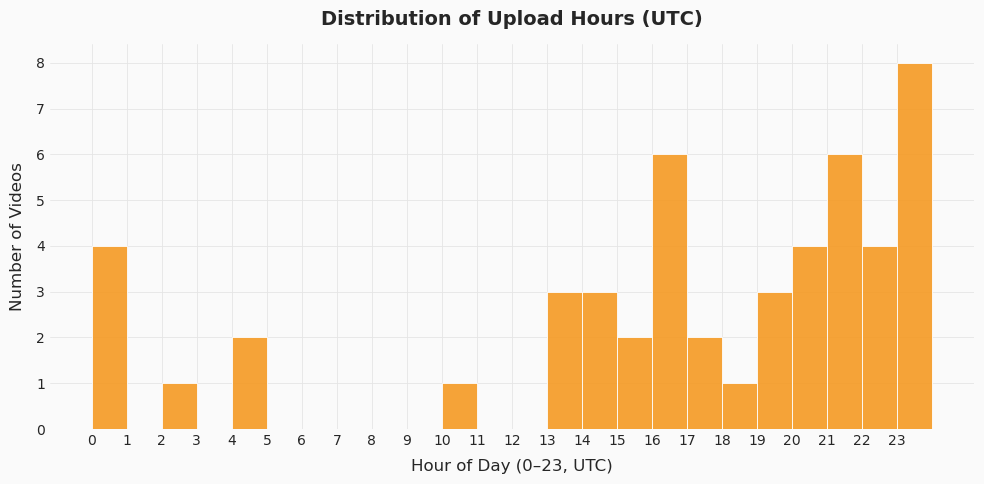

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("statistics")
stats = df_result[['viewCount', 'likeCount', 'commentCount']].describe()
print(stats)

df_result['publishedAt'] = pd.to_datetime(df_result['publishedAt'])
df_result['hour'] = df_result['publishedAt'].dt.hour
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor":   "#FAFAFA",
    "axes.edgecolor":   "#CCCCCC",
    "axes.linewidth":   0.8,
    "grid.color":       "#E5E5E5",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
})

ACCENT   = "#E05C4B"  
ACCENT2  = "#F59A23"   
LABEL_SZ = 12
TITLE_SZ = 14

# GRAPH 1：View Count vs Like Count 
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_result["viewCount"],
    df_result["likeCount"],
    color=ACCENT,
    alpha=0.55,
    s=50,
    edgecolors="white",
    linewidths=0.5,
)

ax.set_title("View Count vs. Like Count (Trending Videos)",
             fontsize=TITLE_SZ, fontweight="bold", pad=14)
ax.set_xlabel("View Count", fontsize=LABEL_SZ, labelpad=8)
ax.set_ylabel("Like Count", fontsize=LABEL_SZ, labelpad=8)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax.tick_params(axis="both", labelsize=10, length=0)
sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

# GRAPH 2：Upload Hour Distribution 
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df_result["hour"],
    bins=24,
    binrange=(0, 24),
    color=ACCENT2,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.9,
    ax=ax,
)

ax.set_title("Distribution of Upload Hours (UTC)",
             fontsize=TITLE_SZ, fontweight="bold", pad=14)
ax.set_xlabel("Hour of Day (0–23, UTC)", fontsize=LABEL_SZ, labelpad=8)
ax.set_ylabel("Number of Videos",        fontsize=LABEL_SZ, labelpad=8)

ax.set_xticks(range(0, 24))
ax.tick_params(axis="both", labelsize=10, length=0)
sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

#### **TASK 1 : Setting up an API key and .env file**
Set up an account and get a free-tier API key at https://marketstack.com/ (no bank details required).

Store the API key in a .env file and load it in your notebook using python-dotenv. Print out only the first 5 characters of the key (e.g. print(api_key[:5] + "...")) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

In [43]:
# Because my jupyter notebook doesn't allow me to store the file with the name ".env", so i created this code to order my computer to make a .env file.

key = "(the api key i'm using)"

with open('.env', 'w') as f:
    f.write(f"api_key={key}")
# by this, i create a local .env file containing my api key 

In [24]:
import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("api_key")

if api_key:
    print(api_key[:5] + "...")

3ec81...


#### **TASK 2 : Retrieving data from MarketStack**
Use the MarketStack API to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

In [122]:
import requests
import pandas as pd

print("Part a and b\n")

# Part a
# set up parameters
url = "http://api.marketstack.com/v1/eod"
params = {
    'access_key': api_key,
    'symbols': 'META,AAPL,AMZN,NFLX,GOOG',
    'date_from': '2026-03-01',
    'date_to': '2026-03-31',
    'limit': 1000
}

# send api request to url 
response = requests.get(url, params=params)
data = response.json()

# Part b
# turn all data into dataframe form
df = pd.df(data['data'])
df['date'] = pd.to_datetime(df['date'])

# print first 5 rows
display(df.head())

print("="*100)
print("Part c")

# group by stock symbol and compute summary statistics for the close(price) column
stats = df.groupby('symbol')['close'].describe()
display(stats)

# calculate the monthly return percentage
def calculation(group):
    # to ensure data is sorted by date to correctly identify the first and last days
    group = group.sort_values('date')
    # identify the closing price on the first and last trading days of the month
    start = group['close'].iloc[0]
    end = group['close'].iloc[-1]
    return ((end - start) / start) * 100
    
# "include_groups=False" excludes the "symbol" column from the calculation
returns = df.groupby('symbol').apply(calculation, include_groups=False)
print(returns)

best = returns.idxmax()
worst = returns.idxmin()
print("-"*100)
print("Performance of 2026.03:")
print("Best Performed Stock: " + best)
print("Worst Performed Stock: " + worst)

Part a and b



,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00


Part c


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


symbol
AAPL    -4.128891
AMZN    -0.057584
GOOG    -6.365061
META   -12.459453
NFLX    -0.968174
dtype: float64
----------------------------------------------------------------------------------------------------
Performance of 2026.03:
Best Performed Stock: AMZN
Worst Performed Stock: META


#### **TASK 3 : Visualizing stock data**
Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

Part a



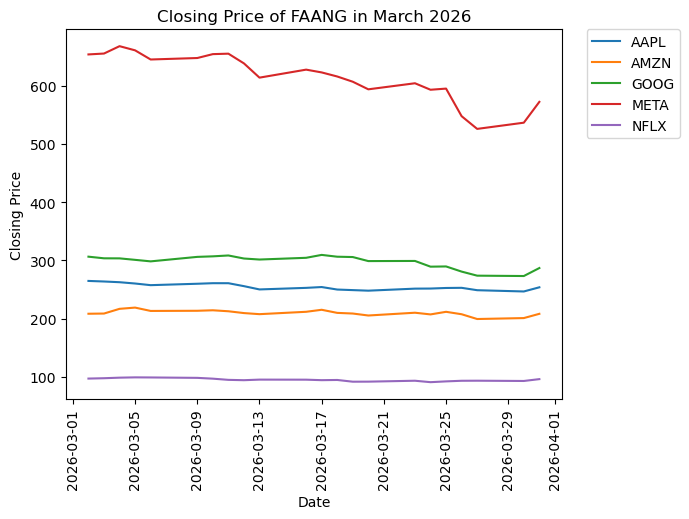

Part b



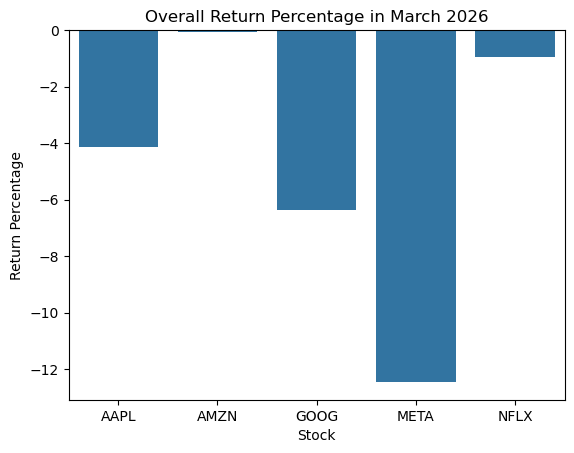

(all return percentages in March 2026 are negative because the market was impacted by the instability taking place in the Middle East region.)
Part c



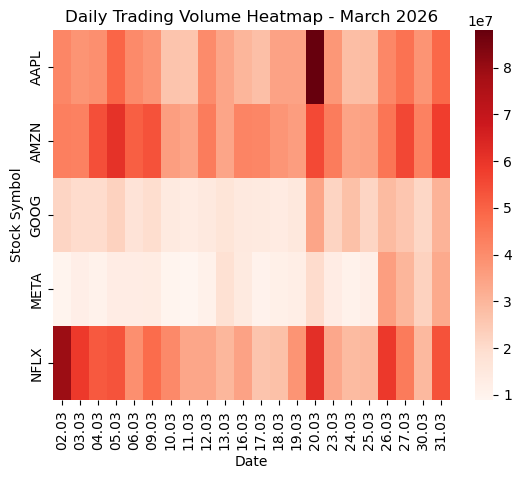

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Task a
print("Part a\n")
sns.lineplot(data=df, x='date', y='close', hue='symbol')
plt.title('Closing Price of FAANG in March 2026')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=90) # rotate the x label by 90 degrees to make it more easy to be seen
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0) # move the legend to right side outside of the graph
plt.show()
print("="*100)

# Task b
print("Part b\n")
sns.barplot(x=returns.index, y=returns.values)
plt.title('Overall Return Percentage in March 2026')
plt.xlabel('Stock')
plt.ylabel('Return Percentage')
plt.show()

print("(all return percentages in March 2026 are negative because the market was impacted by the instability taking place in the Middle East region.)")
print("="*100)

# Task c
print("Part c\n")
pivot = df.pivot(index='symbol', columns='date', values='volume') # using "pivot" to turn all info into metrix
pivot.columns = [d.strftime('%d.%m') for d in pivot.columns] # using "strftime" to turn all dates into date.month(23.03, 01.03, etc.) format

sns.heatmap(volume_pivot, cmap='Reds', annot=False)
plt.title('Daily Trading Volume Heatmap - March 2026')
plt.xlabel('Date')
plt.ylabel('Stock Symbol')
plt.show()

#### **TASK 4 : Exporting and importing data**
a) Export the JSON data retrieved in Task 2a as a JSON file stockdata.json into a subfolder called exports.

b) Export the DataFrame from Task 2b as a CSV file stockdata.csv into the same exports subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [120]:
import os
import json

# Task a
os.makedirs('exports', exist_ok=True)

with open('exports/stockdata.json', 'w') as f:
    json.dump(data, f)

# Task b
df.to_csv('exports/stockdata.csv', index=False) # "index = False" meaning that we're not going to save anything as the index

# Task c
# read json and turn it to DataFrame
with open('exports/stockdata.json', 'r') as f:
    jsondata = json.load(f)
json = pd.DataFrame(jsondata['data'])

print("Part c\n")
print("json: ")
display(json.head())
print("-"*100)
print("")

# load csv
csv = pd.read_csv('exports/stockdata.csv')

print("csv: ")
display(csv.head())

# verification step
print("-" * 100)
print("Verification check passed!!!")

Part c

json: 


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


----------------------------------------------------------------------------------------------------

csv: 


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00


----------------------------------------------------------------------------------------------------
Verification check passed!!!


#### **TASK 5 : Querying the Northwind database**
Download an SQLite version of Microsoft's Northwind database (from https://github.com/jpwhite3/northwind-SQLite3, press the Download Here button). Connect to the database using sqlite3.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing ProductName, UnitPrice, and UnitsInStock. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the Orders, Customers, and Order Details tables to show CompanyName, OrderID, OrderDate, ShipCountry, and the line total (UnitPrice * Quantity) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

In [22]:
import sqlite3
import pandas as pd

# connect to DB
conn = sqlite3.connect('northwind.db')

# Task a
print("Part a\n")

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)
print("="*100)

# Task b
print("Part b\n")
# SQL
query_products = """ 
SELECT ProductName, UnitPrice, UnitsInStock 
FROM Products 
WHERE UnitPrice > 30;
"""

products = pd.read_sql_query(query_products, conn)
print(products)
print("="*100)

# Task c
print("Part c\n")
# SQL
germany = """ 
SELECT c.CompanyName, 
       o.OrderID, 
       o.OrderDate, 
       o.ShipCountry, 
       (od.UnitPrice * od.Quantity) AS TotalLine
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN 'Order Details' od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany';
"""

df_germany = pd.read_sql_query(germany, conn)
print(df_germany)


Part a

                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories
Part b

                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      45.60        

#### **TASK 6 : Visualizing Northwind data**
Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins OrderDetails, Products, and Categories using inner joins to compute the total revenue (UnitPrice * Quantity) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

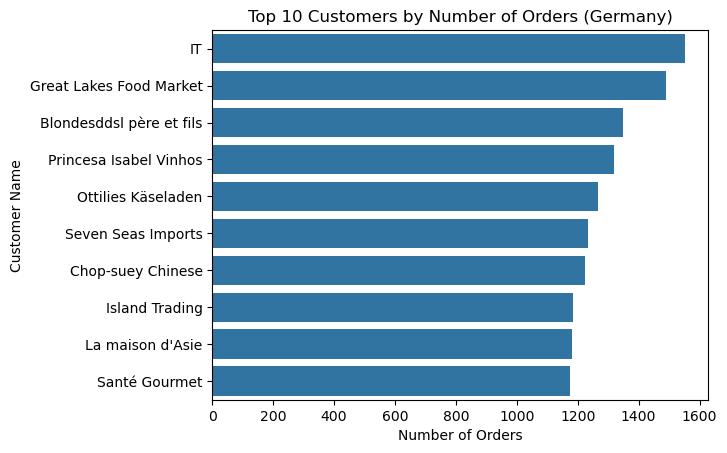

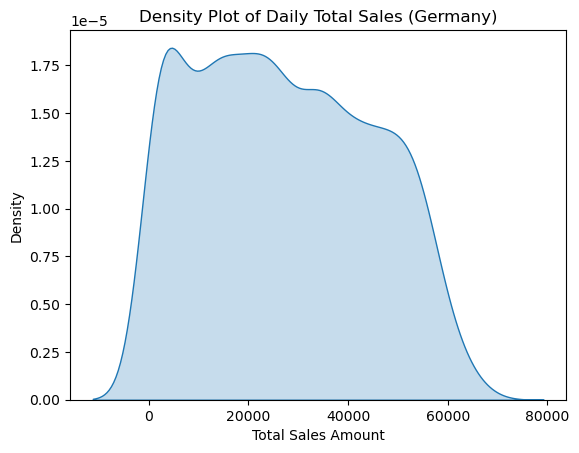

C:\Users\apple\AppData\Local\Temp\ipykernel_16012\1964921787.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_category_revenue, x='TotalRevenue', y='CategoryName', palette='Reds_r')


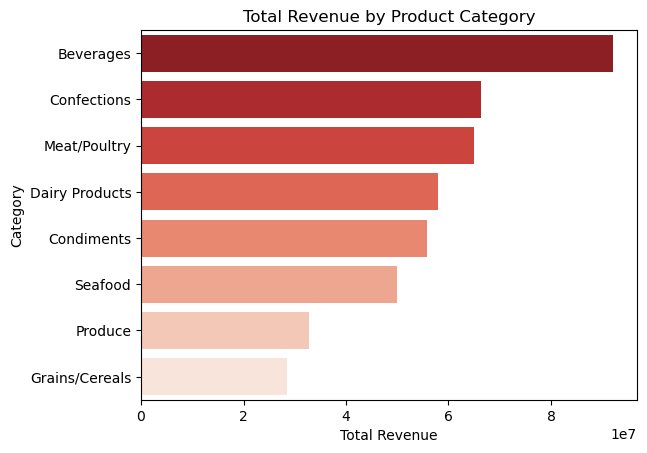

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

# Task a
order_counts = df_germany['CompanyName'].value_counts().head(10)
# draw graph
sns.barplot(x=order_counts.values, y=order_counts.index)
plt.title('Top 10 Customers by Number of Orders in Germany')
plt.xlabel('Number of Orders')
plt.ylabel('Customer')
plt.show()

# Task b
# first grouped by orderdate, and then calculate everyday TotalLine
daily_sales = df_germany.groupby('OrderDate')['TotalLine'].sum()
# draw graph
sns.kdeplot(daily_sales, fill=True)
plt.title('Daily Total Sales in Germany')
plt.xlabel('Total Sales Amount')
plt.ylabel('Density')
plt.show()

# Task c
# SQL
query_category_revenue = """
SELECT c.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC;
"""
category_revenue = pd.read_sql_query(query_category_revenue, conn)
# draw graph
sns.barplot(data=category_revenue, x='TotalRevenue', y='CategoryName', palette='Reds_r')
plt.title('Total Revenue by Product Category')
plt.xlabel('Total Revenue')
plt.ylabel('Category')
plt.show()

#### **TASK 7 : Comparing Python to SQL**
a) Write a SQL query that retrieves the full Products table and the full Categories table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on CategoryID.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using %%time or time.time(), compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [153]:
import pandas as pd
import sqlite3
import time
conn = sqlite3.connect('northwind.db')
# Task a
print("Task a\n")
allproducts = pd.read_sql_query("SELECT * FROM Products", conn)
allctgr = pd.read_sql_query("SELECT * FROM Categories", conn)

display(allproducts.head())
display(allctgr.head())

print("="*100)

# Task b
print("Task b\n")
# inner join on CategoryID
merged = pd.merge(allproducts, allctgr, on='CategoryID', how='inner')
display(merged.head())

print("="*100)

# Task c
print("Task c")
# the spped of using SQL
startt_sql = time.time()
joinedsql = """
SELECT c.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName;
"""
sqlresult = pd.read_sql_query(joinedsql, conn)
endt_sql = time.time()
sqltime = endt_sql - startt_sql

# the speed of using Pandas
startt_p = time.time()
# read 3 sheets
odsheet = pd.read_sql_query("SELECT * FROM 'Order Details'", conn)
productssheet = pd.read_sql_query("SELECT * FROM Products", conn)
ctgrsheet = allctgr

# merge sheets and calculate time used
merged_p = pd.merge(odsheet, productssheet, on='ProductID')
merged_c = pd.merge(merged_p, ctgrsheet, on='CategoryID')
merged_c['Revenue'] = merged_c['UnitPrice_x'] * merged_c['Quantity'] 
productresult = merged_c.groupby('CategoryName')['Revenue'].sum().reset_index()
endt_p = time.time()
producttime = endt_p - startt_p

# outcomes
print("RESULTS：")
print("。The run time of SQL:")
print(f"  {sqltime}")
print("。The run time of Pandas:")
print(f"  {producttime}")
print("COMMENT：\nAccording to the outcomes, we can observe that SQL runs approximately two times faster than Pandas does in this case.")

Task a



,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


Task b



,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


Task c
RESULTS：
。The run time of SQL:
  0.8158938884735107
。The run time of Pandas:
  1.6505951881408691
COMMENT：
According to the outcomes, we can observe that SQL runs approximately two times faster than Pandas does in this case.


#### **TASK 8 : Wide and long format**
a) Convert wide_data from wide to long format using pd.melt(). Print the DataFrame before and after conversion.

b) Convert long_data from long to wide format using .pivot(). Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [2]:
import pandas as pd

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

# Task a
print("Task a: wide_data")
print("original: ")
display(wide_data)

wtol = pd.melt(
    wide_data, 
    id_vars=['store'], 
    var_name='Quarter', 
    value_name='Sales')

print("converted: ")
display(wtol)
print("="*100)

# Task b
print("Task b: long_data")
print("original:")
display(long_data)

ltow = long_data.pivot(
    index='month', 
    columns='product', 
    values='units_sold').reset_index()

print("converted: ")
display(ltow)
print("="*100)

# Task c
print("Task c")
# for wide to long revert
reverted_wide = wtol.pivot(
    index='store', 
    columns='Quarter', 
    values='Sales').reset_index()

# for long to wide revert
reverted_long = pd.melt(
    ltow, 
    id_vars=['month'], 
    var_name='product', 
    value_name='units_sold')

print("Reverted Wide (originally the wide_data):")
display(reverted_wide)

print("Reverted Long (originally the long_data):")
display(reverted_long)

Task a: wide_data
original: 


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


converted: 


,store,Quarter,Sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


Task b: long_data
original:


...

product,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


Task c
Reverted Wide (originally the wide_data):


Quarter,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Reverted Long (originally the long_data):


,month,product,units_sold
0,Feb,Laptop,50
1,Jan,Laptop,45
2,Mar,Laptop,55
3,Feb,Phone,110
4,Jan,Phone,120
5,Mar,Phone,130
